Loaded series length: 3650
Feature matrix shape: (3610, 40)
Target vector shape: (3610,)
Train size: 2888
Test size : 722
Test RMSE: 2.2063


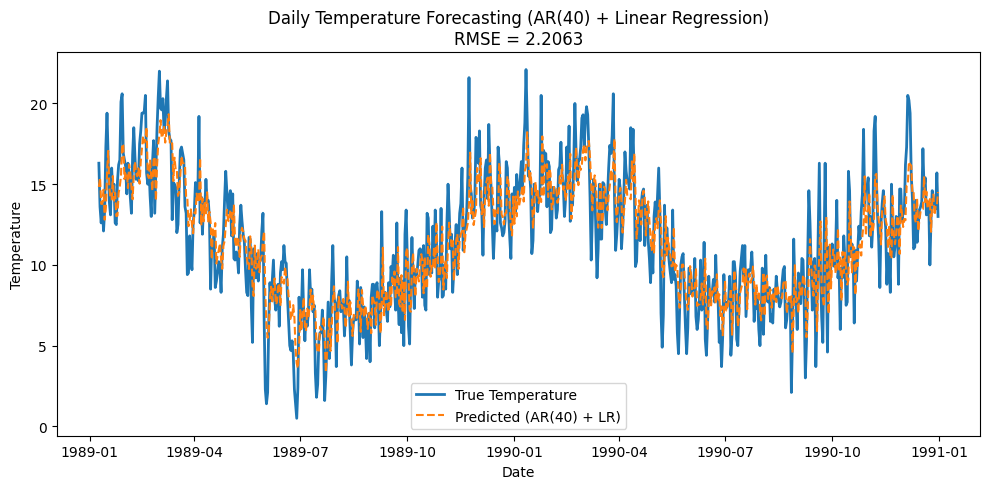

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ======================
# 1. Config
# ======================

CSV_PATH = "dataset.csv"  # <- change to your filename
DATE_COL = "Date"
TEMP_COL = "Temp"

N_LAGS = 40   # AR(1) model: use temp at day T to predict T+1
# you can try N_LAGS = 7, 14, etc. later


# ======================
# 2. Load data
# ======================

df = pd.read_csv(CSV_PATH, parse_dates=[DATE_COL])
df = df.sort_values(DATE_COL)  # ensure chronological order

temp = df[TEMP_COL].values.astype(float)
dates = df[DATE_COL].values

print("Loaded series length:", len(temp))


# ======================
# 3. Build autoregressive dataset
# ======================

def make_ar_dataset(series, n_lags):
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags:t])   # past n_lags temps
        y.append(series[t])              # current temp
    return np.array(X), np.array(y)

X, y = make_ar_dataset(temp, N_LAGS)

# align dates with y (the target at each time step)
dates_target = dates[N_LAGS:]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


# ======================
# 4. Train / test split (time-series)
# ======================

n_samples = X.shape[0]
train_size = int(0.8 * n_samples)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
dates_test = dates_target[train_size:]

print("Train size:", len(y_train))
print("Test size :", len(y_test))


# ======================
# 5. Fit linear regression AR model
# ======================

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ======================
# 6. RMSE
# ======================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Test RMSE: {rmse:.4f}")


# ======================
# 7. Plot predictions vs true values
# ======================

plt.figure(figsize=(10, 5))
plt.plot(dates_test, y_test, label="True Temperature", linewidth=2)
plt.plot(dates_test, y_pred, label=f"Predicted (AR({N_LAGS}) + LR)", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title(f"Daily Temperature Forecasting (AR({N_LAGS}) + Linear Regression)\nRMSE = {rmse:.4f}")
plt.legend()
plt.tight_layout()
plt.show()


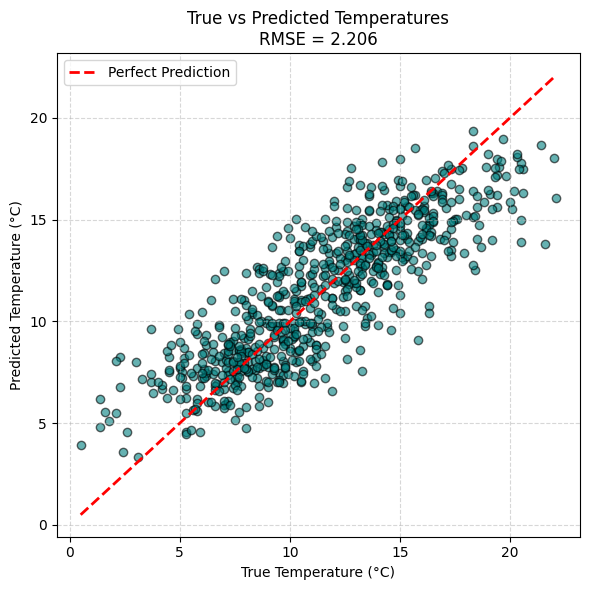

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label="Perfect Prediction")
plt.xlabel("True Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title(f"True vs Predicted Temperatures\nRMSE = {rmse:.3f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


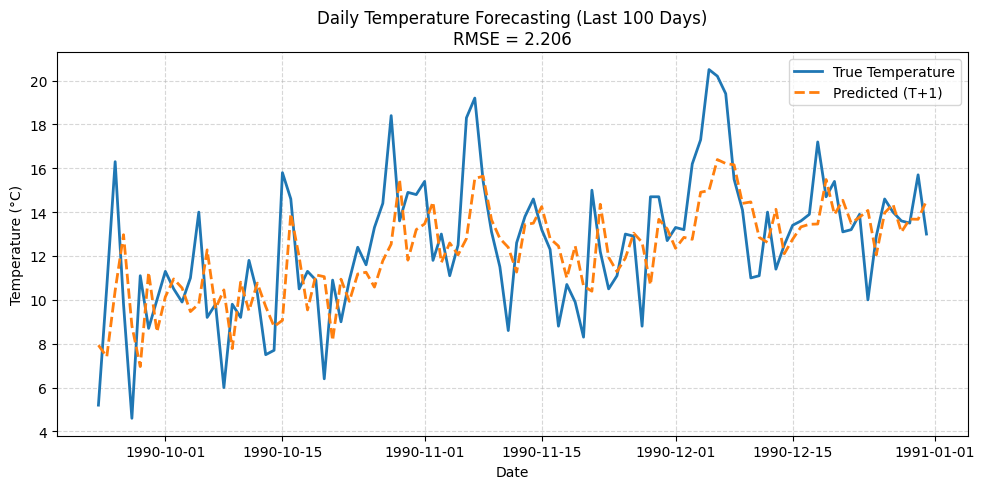

In [16]:
plt.figure(figsize=(10,5))
n_show = 100  # number of last days to show clearly
plt.plot(dates_test[-n_show:], y_test[-n_show:], label="True Temperature", linewidth=2)
plt.plot(dates_test[-n_show:], y_pred[-n_show:], '--', label="Predicted (T+1)", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title(f"Daily Temperature Forecasting (Last {n_show} Days)\nRMSE = {rmse:.3f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
